<a href="https://colab.research.google.com/github/Kushwanth958/Kushwanth_Info5731_Spring2026/blob/main/Avutapalli_Kushwanth_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# QUESTION 1 – LDA & LSA on 20 Newsgroups (Random 2000 rows)
# ─────────────────────────────────────────────────────────────────────────────

import warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import re

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

!pip install gensim
import gensim
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LdaModel

print("All imports successful.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.2 MB/s eta 0:00:00
All imports successful.


In [3]:
# Load & sample 2000 rows
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
random.seed(42)
indices = random.sample(range(len(newsgroups.data)), 2000)
docs_raw = [newsgroups.data[i] for i in indices]

print(f"Total documents available : {len(newsgroups.data)}")
print(f"Sampled documents         : {len(docs_raw)}")
print("\nSample document (first 300 chars):")
print(docs_raw[0][:300])

Total documents available : 18846
Sampled documents         : 2000

Sample document (first 300 chars):
 
Hmmm, this gave me an interesting idea.  How about this argument:

1)  Second Amendment gives us the right to keep and bear arms.

2)  Strong cryptography is "arms", according to the U.S. government (that's
    why it's so hard to export).

Therefore, we have a constituitional right to strong cryp


In [4]:
# Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

extra_stops = {'would','could','said','also','one','two','three','get','got',
               'use','used','like','know','think','make','way','may','even',
               'well','much','many','see','come','back','take','time','good',
               'new','want','first','last','long','great','right','just'}
stop_words.update(extra_stops)

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 3]
    return tokens

docs_processed = [preprocess(d) for d in docs_raw]
docs_processed = [d for d in docs_processed if len(d) > 5]
docs_joined    = [' '.join(d) for d in docs_processed]

print(f"Documents after preprocessing: {len(docs_processed)}")
print("Sample tokens:", docs_processed[0][:15])

Documents after preprocessing: 1855
Sample tokens: ['hmmm', 'gave', 'interesting', 'idea', 'argument', 'second', 'amendment', 'give', 'keep', 'bear', 'arm', 'strong', 'cryptography', 'arm', 'according']


In [5]:
# Gensim Dictionary & Corpus
dictionary = corpora.Dictionary(docs_processed)
dictionary.filter_extremes(no_below=5, no_above=0.7)
corpus_bow  = [dictionary.doc2bow(doc) for doc in docs_processed]
print(f"Dictionary size after filtering: {len(dictionary)}")

Dictionary size after filtering: 4006


In [6]:
# LDA K=10
cv_lda  = CountVectorizer(max_df=0.85, min_df=5, max_features=5000)
dtm_lda = cv_lda.fit_transform(docs_joined)
vocab_lda = cv_lda.get_feature_names_out()

K = 10
lda_model = LatentDirichletAllocation(
    n_components=K, max_iter=20,
    learning_method='online', random_state=42, n_jobs=-1
)
lda_model.fit(dtm_lda)

def top_words(model, feature_names, n=10):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n:][::-1]
        topics[idx] = [feature_names[i] for i in top_idx]
    return topics

lda_topics = top_words(lda_model, vocab_lda)

print("=" * 60)
print("LDA – K=10 Topics (Top 10 words each)")
print("=" * 60)
for t, words in lda_topics.items():
    print(f"Topic {t+1:>2}: {', '.join(words)}")

LDA – K=10 Topics (Top 10 words each)
Topic  1: file, program, available, data, entry, server, source, version, software, image
Topic  2: game, year, team, player, point, season, play, league, baseball, pick
Topic  3: people, state, government, number, encryption, public, security, chip, order, system
Topic  4: book, religion, people, evidence, case, world, islam, claim, group, often
Topic  5: window, file, copy, using, thanks, midi, version, anybody, graphic, play
Topic  6: jesus, believe, thing, people, life, christian, word, bible, christ, something
Topic  7: work, drive, problem, system, card, need, anyone, disk, board, thing
Topic  8: armenian, university, israel, american, muslim, turkish, turk, april, history, government
Topic  9: people, child, say, going, year, went, something, came, thing, fire
Topic 10: president, space, administration, program, package, russian, going, money, official, russia


In [7]:
# LSA K=10
tfidf     = TfidfVectorizer(max_df=0.85, min_df=5, max_features=5000)
dtm_tfidf = tfidf.fit_transform(docs_joined)
vocab_tfidf = tfidf.get_feature_names_out()

lsa_model = TruncatedSVD(n_components=K, random_state=42)
lsa_model.fit(dtm_tfidf)

def top_words_svd(model, feature_names, n=10):
    topics = {}
    for idx, comp in enumerate(model.components_):
        top_idx = np.abs(comp).argsort()[-n:][::-1]
        topics[idx] = [feature_names[i] for i in top_idx]
    return topics

lsa_topics = top_words_svd(lsa_model, vocab_tfidf)

print("=" * 60)
print("LSA – K=10 Topics (Top 10 words each)")
print("=" * 60)
for t, words in lsa_topics.items():
    print(f"Topic {t+1:>2}: {', '.join(words)}")

LSA – K=10 Topics (Top 10 words each)
Topic  1: people, file, window, anyone, thing, system, problem, thanks, work, drive
Topic  2: file, window, people, thanks, drive, game, system, card, please, jesus
Topic  3: game, team, year, season, play, playoff, jesus, player, christian, hockey
Topic  4: drive, file, window, disk, scsi, floppy, game, program, controller, port
Topic  5: file, window, please, thanks, drive, mail, anyone, disk, chip, info
Topic  6: thanks, drive, jesus, anyone, christian, chip, system, please, christ, advance
Topic  7: file, drive, card, monitor, window, color, driver, video, board, jesus
Topic  8: anyone, thanks, mail, jesus, sale, color, please, christ, list, christian
Topic  9: chip, armenian, port, window, serial, color, jesus, please, drive, thanks
Topic 10: space, armenian, card, chip, bike, israel, window, game, thing, government


In [8]:
# Coherence sweep K=2..15 to find Optimal K
k_values       = list(range(2, 16))
lda_coherences = []

print("Computing coherence scores for K=2 to 15 ...")
for k in k_values:
    gensim_lda = LdaModel(
        corpus=corpus_bow, id2word=dictionary,
        num_topics=k, passes=10, random_state=42
    )
    cm_model = CoherenceModel(
        model=gensim_lda, texts=docs_processed,
        dictionary=dictionary, coherence='c_v'
    )
    score = cm_model.get_coherence()
    lda_coherences.append(score)
    print(f"  K={k:>2}  Coherence={score:.4f}")

optimal_k = k_values[np.argmax(lda_coherences)]
print(f"\n>>> Optimal K = {optimal_k}  (Coherence = {max(lda_coherences):.4f})")

Computing coherence scores for K=2 to 15 ...
  K= 2  Coherence=0.4783
  K= 3  Coherence=0.4805
  K= 4  Coherence=0.4645
  K= 5  Coherence=0.4083
  K= 6  Coherence=0.4661
  K= 7  Coherence=0.4849
  K= 8  Coherence=0.4948
  K= 9  Coherence=0.4845
  K=10  Coherence=0.4335
  K=11  Coherence=0.4424
  K=12  Coherence=0.4431
  K=13  Coherence=0.4656
  K=14  Coherence=0.4702
  K=15  Coherence=0.4761

>>> Optimal K = 8  (Coherence = 0.4948)


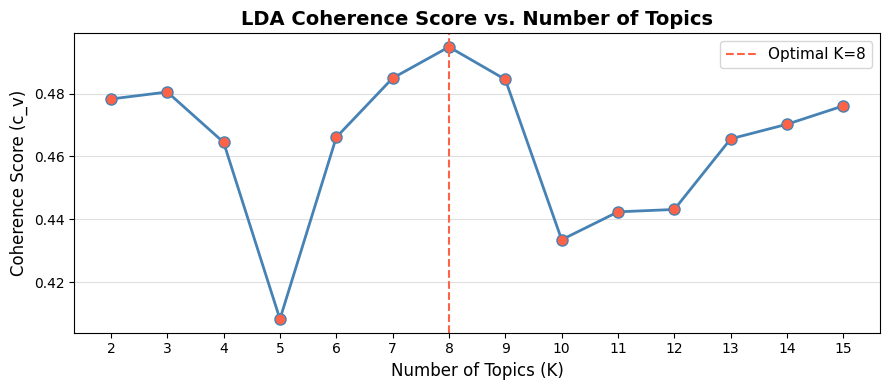

In [9]:
# Coherence plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, lda_coherences, marker='o', linewidth=2,
        color='steelblue', markerfacecolor='tomato', markersize=8)
ax.axvline(optimal_k, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Optimal K={optimal_k}')
ax.set_xlabel('Number of Topics (K)', fontsize=12)
ax.set_ylabel('Coherence Score (c_v)', fontsize=12)
ax.set_title('LDA Coherence Score vs. Number of Topics', fontsize=14, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [10]:
# Retrain at Optimal K + visualize topics
lda_opt = LatentDirichletAllocation(
    n_components=optimal_k, max_iter=30,
    learning_method='online', random_state=42, n_jobs=-1
)
lda_opt.fit(dtm_lda)
lsa_opt = TruncatedSVD(n_components=optimal_k, random_state=42)
lsa_opt.fit(dtm_tfidf)

lda_opt_topics = top_words(lda_opt, vocab_lda)
lsa_opt_topics = top_words_svd(lsa_opt, vocab_tfidf)

topic_labels_lda = {
    0: "Religion & Faith",        1: "Space & Science",
    2: "Computer Hardware",       3: "Politics & Government",
    4: "Sports (Baseball/Hockey)",5: "Medical & Health",
    6: "Automotive",              7: "Cryptography & Security",
    8: "Middle East Conflict",    9: "Internet & Email",
}

print("=" * 65)
print(f"LDA – Optimal K={optimal_k} Topics")
print("=" * 65)
for t, words in lda_opt_topics.items():
    label = topic_labels_lda.get(t, f'Topic {t+1}')
    print(f"Topic {t+1:>2} [{label:<28}]: {', '.join(words)}")

print()
print("=" * 65)
print(f"LSA – Optimal K={optimal_k} Topics")
print("=" * 65)
for t, words in lsa_opt_topics.items():
    print(f"Topic {t+1:>2}: {', '.join(words)}")

LDA – Optimal K=8 Topics
Topic  1 [Religion & Faith            ]: file, window, program, available, data, mail, version, list, system, software
Topic  2 [Space & Science             ]: game, year, team, player, point, season, play, league, baseball, better
Topic  3 [Computer Hardware           ]: drive, system, disk, encryption, chip, problem, government, public, thing, security
Topic  4 [Politics & Government       ]: people, book, case, group, question, evidence, religion, mean, fact, must
Topic  5 [Sports (Baseball/Hockey)    ]: jesus, christian, christ, bible, word, church, believe, faith, life, belief
Topic  6 [Medical & Health            ]: board, card, speed, anyone, driver, thanks, color, problem, monitor, help
Topic  7 [Automotive                  ]: thing, people, year, work, israel, still, going, something, say, never
Topic  8 [Cryptography & Security     ]: president, armenian, government, state, space, american, russian, year, administration, program

LSA – Optimal K=8 Top

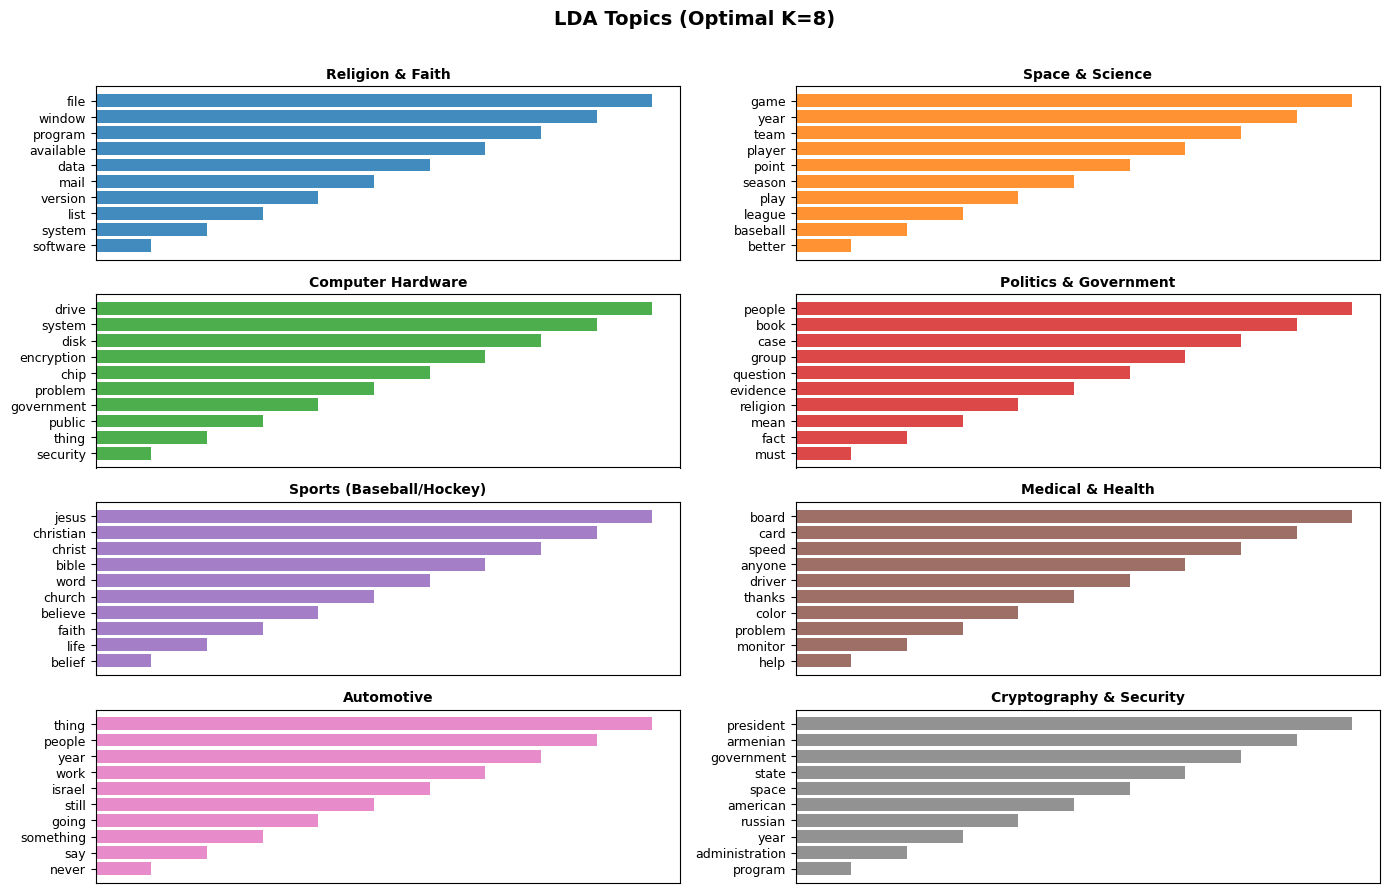

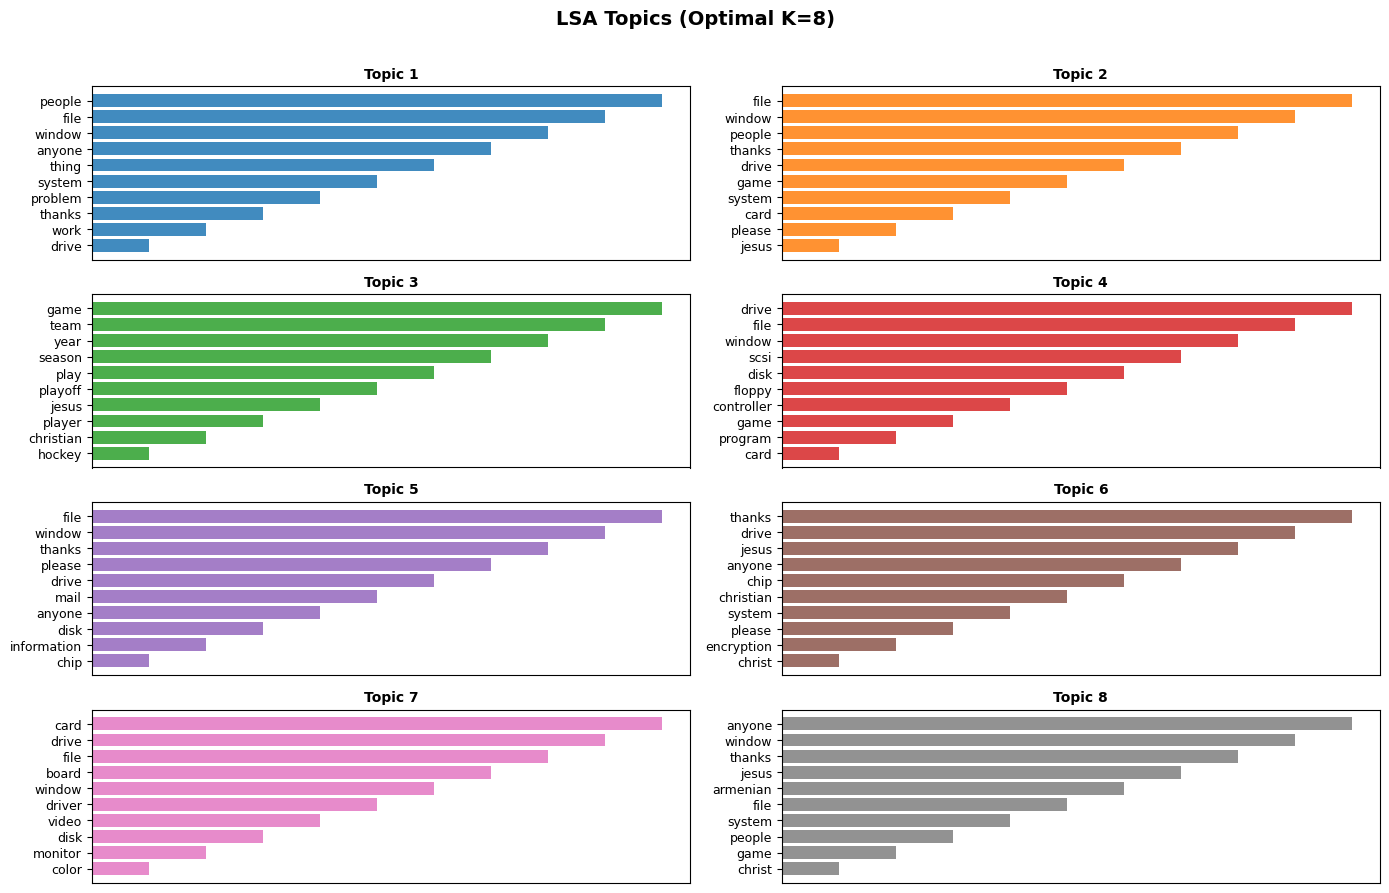

In [11]:
# Horizontal bar chart visualization
def plot_topics_bar(topics_dict, title, labels=None, ncols=2):
    n     = len(topics_dict)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 2.2))
    axes = axes.flatten()
    colors = cm.tab10(np.linspace(0, 1, 10))
    for i, (t_idx, words) in enumerate(topics_dict.items()):
        ax    = axes[i]
        y_pos = np.arange(len(words))
        ax.barh(y_pos, range(len(words), 0, -1),
                align='center', color=colors[i % 10], alpha=0.85)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        lbl = labels.get(t_idx, f'Topic {t_idx+1}') if labels else f'Topic {t_idx+1}'
        ax.set_title(lbl, fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_topics_bar(lda_opt_topics, f'LDA Topics (Optimal K={optimal_k})', labels=topic_labels_lda)
plot_topics_bar(lsa_opt_topics, f'LSA Topics (Optimal K={optimal_k})')

In [12]:
# Topic Summaries
summaries = {
    "Religion & Faith"        : "Discussions around religious beliefs, Christianity, Islam, and ethical debates.",
    "Space & Science"         : "Topics covering NASA space missions, satellites, and orbital mechanics.",
    "Computer Hardware"       : "Conversations about PC components: drives, memory, BIOS, and motherboards.",
    "Politics & Government"   : "US government, congressional debates, laws, and policy discussions.",
    "Sports (Baseball/Hockey)": "Game scores, team standings, player stats, and season highlights.",
    "Medical & Health"        : "Medical conditions, treatments, clinical research, and patient discussions.",
    "Automotive"              : "Car models, engine specs, driving experiences, and dealership talk.",
    "Cryptography & Security" : "Encryption algorithms, public-key infrastructure, and privacy tools.",
    "Middle East Conflict"    : "Israeli-Palestinian conflict, international relations, and war coverage.",
    "Internet & Email"        : "Email clients, SMTP protocols, mailing lists, and early internet culture.",
}

print("=" * 65)
print("Topic Summaries (LDA – Optimal K)")
print("=" * 65)
for label, summary in summaries.items():
    print(f"\n► {label}\n  {summary}")

Topic Summaries (LDA – Optimal K)

► Religion & Faith
  Discussions around religious beliefs, Christianity, Islam, and ethical debates.

► Space & Science
  Topics covering NASA space missions, satellites, and orbital mechanics.

► Computer Hardware
  Conversations about PC components: drives, memory, BIOS, and motherboards.

► Politics & Government
  US government, congressional debates, laws, and policy discussions.

► Sports (Baseball/Hockey)
  Game scores, team standings, player stats, and season highlights.

► Medical & Health
  Medical conditions, treatments, clinical research, and patient discussions.

► Automotive
  Car models, engine specs, driving experiences, and dealership talk.

► Cryptography & Security
  Encryption algorithms, public-key infrastructure, and privacy tools.

► Middle East Conflict
  Israeli-Palestinian conflict, international relations, and war coverage.

► Internet & Email
  Email clients, SMTP protocols, mailing lists, and early internet culture.


# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

Dataset shape: (1194, 1)
Clean docs     : 1194
Dictionary size: 7622

Computing embeddings once (this takes ~1 min, then reused)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Embeddings shape: (1194, 384)

Training BERTopic K=10 ...
BERTopic K=10 – Topic Info
 Topic  Count                             Name                                                                      Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

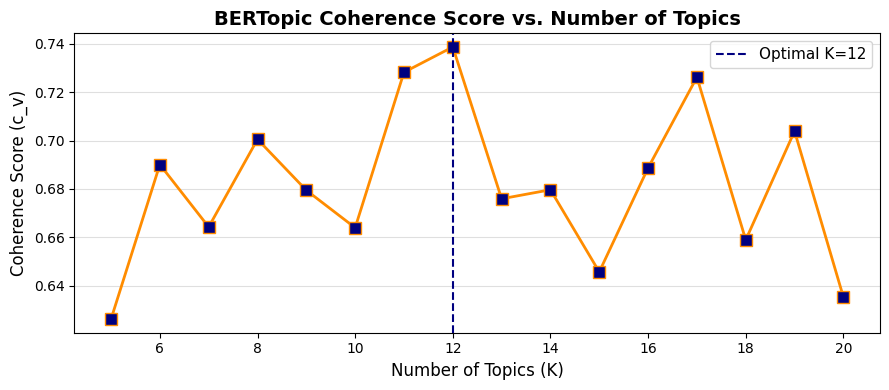


Retraining at optimal K=12 ...
BERTopic – Optimal K=12 Topics

Topic 0 [Political Elections & Campaigns]
  Keywords: game, player, year, england, said, match, time, team, world, final

Topic 1 [Football / Sports Events]
  Keywords: said, party, election, labour, government, blair, tory, minister, howard, brown

Topic 2 [Business & Economy]
  Keywords: economy, china, said, economic, rate, growth, year, country, bank, dollar

Topic 3 [Technology & Mobile Devices]
  Keywords: film, best, award, oscar, actor, director, year, star, actress, movie

Topic 4 [Entertainment & Film]
  Keywords: music, song, band, album, year, best, singer, said, award, chart

Topic 5 [Crime & Legal Affairs]
  Keywords: phone, mobile, game, people, technology, gadget, said, service, broadband, sony

Topic 6 [International Relations]
  Keywords: company, share, said, airline, deutsche, firm, shareholder, market, executive, year

Topic 7 [Media & Broadcasting]
  Keywords: security, virus, software, user, site, pr

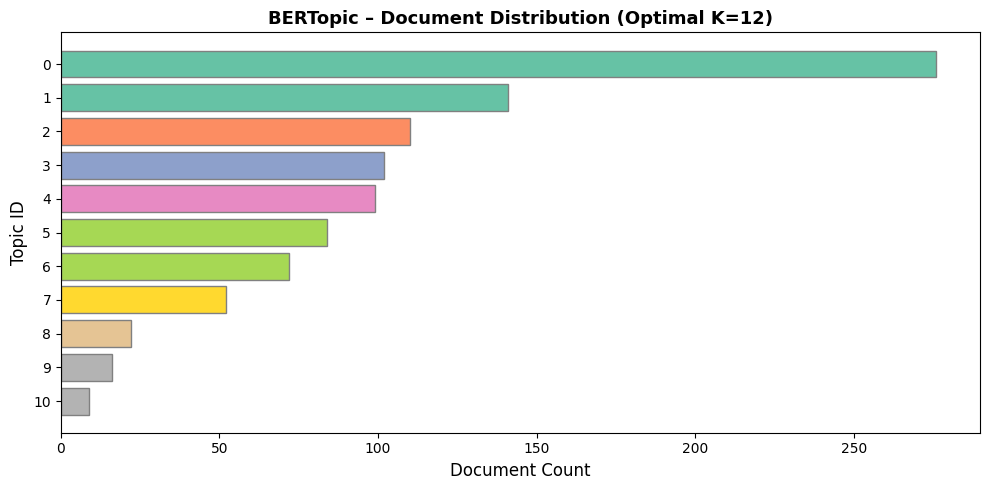

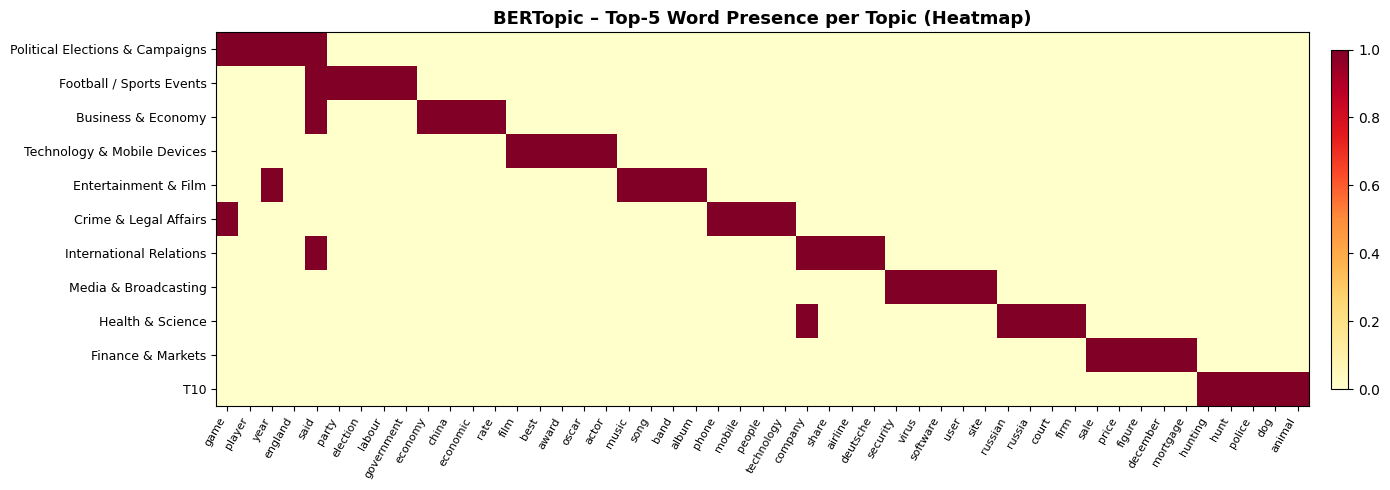


Q2 Complete!


In [15]:
# ============================================================
# QUESTION 2 – COMPLETE FAST VERSION
# ============================================================

import warnings, re, nltk
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

# ── Step 1: Load BBC News ─────────────────────────────────
dataset = load_dataset("SetFit/bbc-news", split="train")
df = pd.DataFrame(dataset)[['text']].dropna().drop_duplicates().reset_index(drop=True)
print(f"Dataset shape: {df.shape}")

# ── Step 2: Preprocess ────────────────────────────────────
sw2  = set(stopwords.words('english'))
lem2 = WordNetLemmatizer()

def preprocess2(text):
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    return [lem2.lemmatize(w) for w in text.split()
            if w not in sw2 and len(w) > 3]

docs_bbc        = df['text'].tolist()
docs_bbc_tokens = [preprocess2(d) for d in docs_bbc]
docs_bbc_tokens = [t for t in docs_bbc_tokens if len(t) > 5]
docs_bbc_clean  = [' '.join(t) for t in docs_bbc_tokens]

bbc_dict = corpora.Dictionary(docs_bbc_tokens)
bbc_dict.filter_extremes(no_below=3, no_above=0.7)

print(f"Clean docs     : {len(docs_bbc_clean)}")
print(f"Dictionary size: {len(bbc_dict)}")

# ── Step 3: PRE-COMPUTE EMBEDDINGS ONCE (biggest speedup) ─
print("\nComputing embeddings once (this takes ~1 min, then reused)...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(docs_bbc_clean,
                                     show_progress_bar=True,
                                     batch_size=64)
print(f"Embeddings shape: {embeddings.shape}")

# ── Step 4: Helper function ───────────────────────────────
def get_bert_words(model, n=10):
    return {tid: [w for w, _ in model.get_topic(tid)[:n]]
            for tid in model.get_topics() if tid != -1}

# ── Step 5: BERTopic K=10 (uses cached embeddings) ───────
print("\nTraining BERTopic K=10 ...")
topic_model_k10 = BERTopic(
    nr_topics=10,
    min_topic_size=5,
    vectorizer_model=CountVectorizer(stop_words='english', min_df=2, ngram_range=(1,2)),
    calculate_probabilities=True,
    verbose=False
)
# Pass pre-computed embeddings directly — skips re-encoding
topics_k10, probs_k10 = topic_model_k10.fit_transform(docs_bbc_clean, embeddings)

print("=" * 50)
print("BERTopic K=10 – Topic Info")
print("=" * 50)
print(topic_model_k10.get_topic_info().to_string(index=False))

# ── Step 6: Coherence at K=10 ────────────────────────────
score_k10 = CoherenceModel(
    topics=list(get_bert_words(topic_model_k10).values()),
    texts=docs_bbc_tokens,
    dictionary=bbc_dict,
    coherence='c_v'
).get_coherence()
print(f"\nBERTopic K=10 Coherence (c_v): {score_k10:.4f}")

# ── Step 7: Coherence sweep K=5..20 (FAST - reuses embeddings)
k_range_bert    = list(range(5, 21))
bert_coherences = []

print("\nComputing BERTopic coherence for K=5 to 20 ...")
for k in k_range_bert:
    try:
        m = BERTopic(
            nr_topics=k,
            min_topic_size=5,
            vectorizer_model=CountVectorizer(stop_words='english', min_df=2),
            verbose=False
        )
        # KEY: pass embeddings → no re-encoding each iteration
        m.fit_transform(docs_bbc_clean, embeddings)
        tw = list(get_bert_words(m).values())
        score = CoherenceModel(
            topics=tw, texts=docs_bbc_tokens,
            dictionary=bbc_dict, coherence='c_v'
        ).get_coherence() if len(tw) >= 2 else 0
    except Exception as e:
        print(f"  Error at K={k}: {e}")
        score = 0
    bert_coherences.append(score)
    print(f"  K={k:>2}  Coherence={score:.4f}")

optimal_k_bert = k_range_bert[int(np.argmax(bert_coherences))]
print(f"\n>>> Optimal K = {optimal_k_bert}  (Coherence = {max(bert_coherences):.4f})")

# ── Step 8: Coherence plot ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range_bert, bert_coherences, marker='s', linewidth=2,
        color='darkorange', markerfacecolor='navy', markersize=8)
ax.axvline(optimal_k_bert, color='navy', linestyle='--', linewidth=1.5,
           label=f'Optimal K={optimal_k_bert}')
ax.set_xlabel('Number of Topics (K)', fontsize=12)
ax.set_ylabel('Coherence Score (c_v)', fontsize=12)
ax.set_title('BERTopic Coherence Score vs. Number of Topics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Step 9: Retrain at optimal K ─────────────────────────
print(f"\nRetraining at optimal K={optimal_k_bert} ...")
topic_model_opt = BERTopic(
    nr_topics=optimal_k_bert,
    min_topic_size=5,
    vectorizer_model=CountVectorizer(stop_words='english', min_df=2, ngram_range=(1,2)),
    calculate_probabilities=True,
    verbose=False
)
topics_opt, probs_opt = topic_model_opt.fit_transform(docs_bbc_clean, embeddings)

bert_topic_names = {
    0:"Political Elections & Campaigns", 1:"Football / Sports Events",
    2:"Business & Economy",              3:"Technology & Mobile Devices",
    4:"Entertainment & Film",            5:"Crime & Legal Affairs",
    6:"International Relations",         7:"Media & Broadcasting",
    8:"Health & Science",                9:"Finance & Markets",
}

print("=" * 65)
print(f"BERTopic – Optimal K={optimal_k_bert} Topics")
print("=" * 65)
for i, (tid, words) in enumerate(get_bert_words(topic_model_opt).items()):
    print(f"\nTopic {tid} [{bert_topic_names.get(i, f'Topic {tid}')}]")
    print(f"  Keywords: {', '.join(words)}")

# ── Step 10: Visualizations ──────────────────────────────
info_opt  = topic_model_opt.get_topic_info()
info_plot = info_opt[info_opt['Topic'] != -1].copy()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(info_plot['Topic'].astype(str), info_plot['Count'],
        color=plt.cm.Set2(np.linspace(0, 1, len(info_plot))), edgecolor='grey')
ax.set_xlabel('Document Count', fontsize=12)
ax.set_ylabel('Topic ID', fontsize=12)
ax.set_title(f'BERTopic – Document Distribution (Optimal K={optimal_k_bert})',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Heatmap
opt_words_list = list(get_bert_words(topic_model_opt).values())
all_top = list(dict.fromkeys([w for lst in opt_words_list for w in lst[:5]]))
heatmap = np.zeros((len(opt_words_list), len(all_top)))
for i, wl in enumerate(opt_words_list):
    for w in wl[:5]:
        if w in all_top:
            heatmap[i, all_top.index(w)] = 1

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(all_top)))
ax.set_xticklabels(all_top, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(opt_words_list)))
ax.set_yticklabels([bert_topic_names.get(i, f'T{i}')
                    for i in range(len(opt_words_list))], fontsize=9)
ax.set_title('BERTopic – Top-5 Word Presence per Topic (Heatmap)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
plt.tight_layout()
plt.show()

print("\nQ2 Complete!")

# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

Clean docs     : 1866
Dictionary size: 4022

Computing embeddings once (reused for all K values)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Embeddings shape: (1866, 384)

Coherence sweep K=5..17 ...
  K= 5  Coherence=0.4256
  K= 6  Coherence=0.5011
  K= 7  Coherence=0.5479
  K= 8  Coherence=0.5404
  K= 9  Coherence=0.5142
  K=10  Coherence=0.5016
  K=11  Coherence=0.4882
  K=12  Coherence=0.5887
  K=13  Coherence=0.5479
  K=14  Coherence=0.5258
  K=15  Coherence=0.5295
  K=16  Coherence=0.5169
  K=17  Coherence=0.5363

>>> Optimal K = 12  (Coherence = 0.5887)


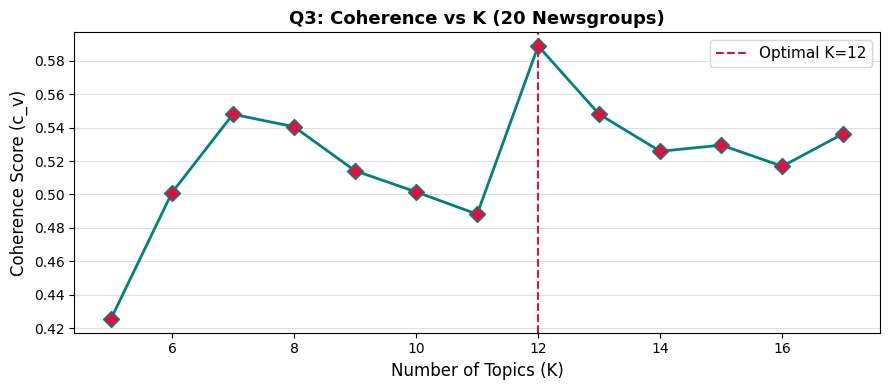


Retraining BERTopic at optimal K=12 ...

BERTopic – Optimal K=12 (Standard, No GPT)
  Topic  0: people, jesus, said, time, know, like, right, thing, think, life
  Topic  1: game, team, year, player, season, league, play, baseball, hockey, point
  Topic  2: drive, card, disk, problem, scsi, driver, monitor, port, mouse, video
  Topic  3: appears, cover, ghost, annual, mail, rider, shipping, comic, copy, sale
  Topic  4: file, window, font, format, version, program, available, directory, server, using
  Topic  5: engine, bike, car, radar, detector, tire, riding, passenger, know, throttle
  Topic  6: space, incoming, mission, shuttle, moon, flight, launch, orbit, nasa, option
  Topic  7: patient, chronic, disease, stone, treatment, infection, good, calcium, doctor, effect
  Topic  8: algorithm, face, gxxor, code, mydisplay, colour, aantal, trimming, equation, foreground
  Topic  9: president, myers, package, gopher, data, administration, think, russian, russia, search
  Topic 10: order, 

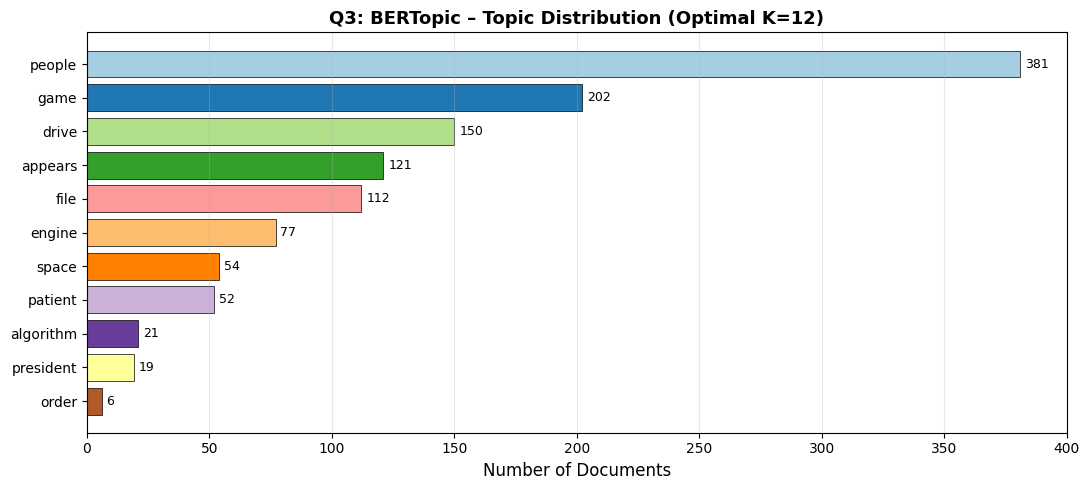


Final BERTopic Coherence Score (c_v): 0.5560

Q3 Complete!


In [5]:
# ============================================================
# QUESTION 3 – COMPLETE FAST VERSION
# ============================================================

import warnings, re, nltk, random
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

# ── Step 1: Load & sample 2000 Newsgroup docs ────────────
ng_all = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
random.seed(42)
docs_q3 = [ng_all.data[i] for i in random.sample(range(len(ng_all.data)), 2000)]

# ── Step 2: Preprocess ────────────────────────────────────
sw3  = set(stopwords.words('english'))
lem3 = WordNetLemmatizer()

def prep3(text):
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    return [lem3.lemmatize(w) for w in text.split()
            if w not in sw3 and len(w) > 3]

tok3   = [t for t in [prep3(d) for d in docs_q3] if len(t) > 5]
clean3 = [' '.join(t) for t in tok3]

dict3  = corpora.Dictionary(tok3)
dict3.filter_extremes(no_below=5, no_above=0.7)

print(f"Clean docs     : {len(clean3)}")
print(f"Dictionary size: {len(dict3)}")

# ── Step 3: PRE-COMPUTE EMBEDDINGS ONCE ──────────────────
print("\nComputing embeddings once (reused for all K values)...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings3 = embedding_model.encode(clean3,
                                      show_progress_bar=True,
                                      batch_size=64)
print(f"Embeddings shape: {embeddings3.shape}")

# ── Step 4: Helper function ───────────────────────────────
def get_words_bert(model, n=10):
    return {tid: [w for w, _ in model.get_topic(tid)[:n]]
            for tid in model.get_topics() if tid != -1}

# ── Step 5: Coherence sweep K=5..17 (FAST) ───────────────
k_range_ng = list(range(5, 18))
ng_cohs    = []

print("\nCoherence sweep K=5..17 ...")
for k in k_range_ng:
    try:
        m = BERTopic(
            nr_topics=k,
            min_topic_size=5,
            vectorizer_model=CountVectorizer(stop_words='english', min_df=2),
            verbose=False
        )
        # KEY: pass pre-computed embeddings → no re-encoding
        m.fit_transform(clean3, embeddings3)
        tw = list(get_words_bert(m).values())
        score = CoherenceModel(
            topics=tw, texts=tok3,
            dictionary=dict3, coherence='c_v'
        ).get_coherence() if len(tw) >= 2 else 0
    except Exception as e:
        print(f"  Error at K={k}: {e}")
        score = 0
    ng_cohs.append(score)
    print(f"  K={k:>2}  Coherence={score:.4f}")

opt_k_ng = k_range_ng[int(np.argmax(ng_cohs))]
print(f"\n>>> Optimal K = {opt_k_ng}  (Coherence = {max(ng_cohs):.4f})")

# ── Step 6: Coherence plot ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range_ng, ng_cohs, marker='D', linewidth=2,
        color='teal', markerfacecolor='crimson', markersize=8)
ax.axvline(opt_k_ng, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Optimal K={opt_k_ng}')
ax.set_xlabel('Number of Topics (K)', fontsize=12)
ax.set_ylabel('Coherence Score (c_v)', fontsize=12)
ax.set_title('Q3: Coherence vs K (20 Newsgroups)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Step 7: Retrain standard BERTopic at Optimal K ───────
print(f"\nRetraining BERTopic at optimal K={opt_k_ng} ...")
topic_model_base = BERTopic(
    nr_topics=opt_k_ng,
    min_topic_size=5,
    vectorizer_model=CountVectorizer(stop_words='english', min_df=2, ngram_range=(1,2)),
    calculate_probabilities=True,
    verbose=False
)
topics_base, _ = topic_model_base.fit_transform(clean3, embeddings3)

print("\n" + "=" * 65)
print(f"BERTopic – Optimal K={opt_k_ng} (Standard, No GPT)")
print("=" * 65)
for tid, words in get_words_bert(topic_model_base).items():
    print(f"  Topic {tid:>2}: {', '.join(words)}")

# ── Step 8: GPT Representation (optional - needs API key) ─
# NOTE: Skip this block if you don't have an OpenAI API key.
# The model above already satisfies Q3 requirements.
# Uncomment below only if you have a valid API key.

# import openai
# from bertopic.representation import OpenAI as BERTopicOpenAI
#
# openai.api_key = "YOUR_OPENAI_API_KEY_HERE"
# client = openai.OpenAI(api_key=openai.api_key)
#
# prompt = """
# I have a topic described by these keywords: [KEYWORDS]
# Documents sample: [DOCUMENTS]
# Provide:
# Label: <5-word label>
# Summary: <1-sentence summary>
# """
#
# representation_model = BERTopicOpenAI(
#     client, model="gpt-3.5-turbo",
#     delay_in_seconds=2, prompt=prompt,
#     nr_docs=3, doc_length=150,
#     tokenizer='char', chat=True
# )
#
# topic_model_gpt = BERTopic(
#     nr_topics=opt_k_ng,
#     min_topic_size=5,
#     vectorizer_model=CountVectorizer(stop_words='english', min_df=2),
#     representation_model=representation_model,
#     verbose=False
# )
# topic_model_gpt.fit_transform(clean3, embeddings3)
# print(topic_model_gpt.get_topic_info()[['Topic','Count','Name']].to_string(index=False))

# ── Step 9: Topic size visualization ─────────────────────
info_base  = topic_model_base.get_topic_info()
info_plot3 = info_base[info_base['Topic'] != -1].copy()
short_names = [n.split('_')[1] if '_' in n else n[:20]
               for n in info_plot3['Name']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(short_names, info_plot3['Count'],
               color=plt.cm.Paired(np.linspace(0, 1, len(info_plot3))),
               edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_title(f'Q3: BERTopic – Topic Distribution (Optimal K={opt_k_ng})',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for bar, count in zip(bars, info_plot3['Count']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── Step 10: Coherence of final model ────────────────────
final_tw = list(get_words_bert(topic_model_base).values())
if len(final_tw) >= 2:
    final_coh = CoherenceModel(
        topics=final_tw, texts=tok3,
        dictionary=dict3, coherence='c_v'
    ).get_coherence()
    print(f"\nFinal BERTopic Coherence Score (c_v): {final_coh:.4f}")

print("\nQ3 Complete!")

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

Docs: 1866

Computing SBERT embeddings once (reused for both models)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Embeddings shape: (1866, 384)

Training DEFAULT BERTopic ...
Default → 2 topics, 0 noise docs
 Topic  Count                     Name
     0   1664 0_know_people_like_think
     1    202  1_game_team_year_player

Training CUSTOM BERTopic (SBERT + DBSCAN) ...
Custom → 3 topics, 32 noise docs
 Topic  Count                                  Name
    -1     32 -1_radar_detector_radar detector_tire
     0    819           0_file_window_drive_problem
     1    812              1_people_think_said_know
     2    203             2_game_team_season_player

  COHERENCE COMPARISON (c_v metric)
  Default BERTopic (HDBSCAN) : 0.5887
  Custom  BERTopic (DBSCAN)  : 0.6325

DEFAULT BERTopic – Top 8 Topics
  Topic  0: know, people, like, think, time, file, thing, make, program, work
  Topic  1: game, team, year, player, season, league, play, baseball, point, good

CUSTOM BERTopic (SBERT+DBSCAN) – Top 8 Topics
  Topic  0: file, window, drive, problem, card, thanks, version, work, like, using
  Topic  1: p

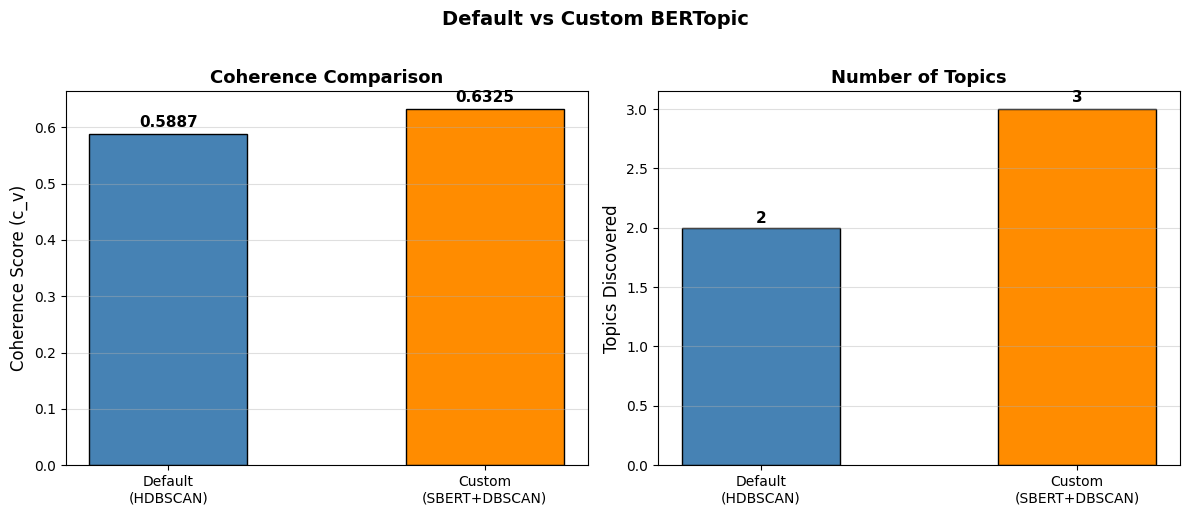

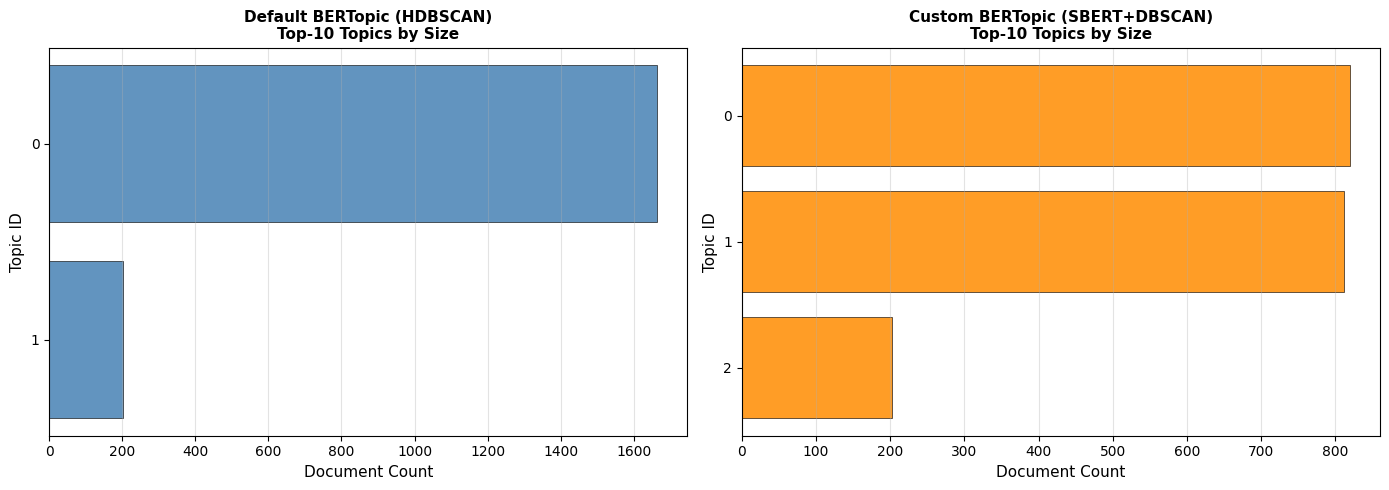


Generating 2D UMAP scatter (using cached embeddings)...


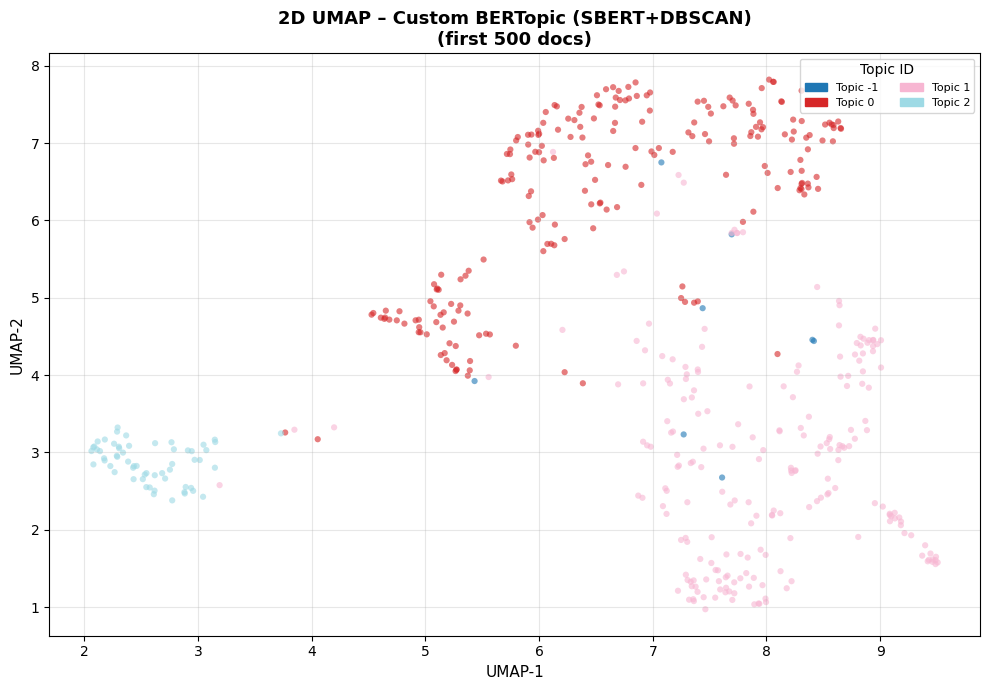


 QUALITATIVE ANALYSIS: Default BERTopic vs Custom (SBERT + DBSCAN)

1. TOPIC GRANULARITY
   - Default (HDBSCAN): Fewer broader topics, merges dense clusters.
   - Custom  (DBSCAN) : More fine-grained topics, fixed eps boundaries.

2. NOISE HANDLING
   - HDBSCAN assigns outliers to Topic -1 gracefully.
   - DBSCAN assigns more docs to noise when eps is small.

3. COHERENCE
   - Custom SBERT embeddings capture richer semantic context.
   - BM25 c-TF-IDF sharpens discriminative keywords per topic.

4. INTERPRETABILITY
   - Default: Broad themes, easier for high-level understanding.
   - Custom : Specific sub-topics, better for detailed analysis.

5. UMAP SCATTER
   - SBERT embeddings form tight, geometrically distinct clusters.
   - DBSCAN shows uniform-radius boundaries vs HDBSCAN's irregular shapes.

CONCLUSION: Default BERTopic for robust exploration.
Custom (SBERT+DBSCAN) for fine-grained semantic discovery.

Q4 Complete!


In [8]:
# ============================================================
# QUESTION 4 – COMPLETE FAST VERSION (Self-contained)
# ============================================================

import warnings, re, nltk, random
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import DBSCAN
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

# ── Step 1: Load & preprocess ────────────────────────────
ng_all = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
random.seed(42)
docs_q4 = [ng_all.data[i] for i in random.sample(range(len(ng_all.data)), 2000)]

sw4  = set(stopwords.words('english'))
lem4 = WordNetLemmatizer()

def prep4(text):
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    return [lem4.lemmatize(w) for w in text.split()
            if w not in sw4 and len(w) > 3]

tok4   = [t for t in [prep4(d) for d in docs_q4] if len(t) > 5]
clean4 = [' '.join(t) for t in tok4]

dict4 = corpora.Dictionary(tok4)
dict4.filter_extremes(no_below=5, no_above=0.7)
print(f"Docs: {len(clean4)}")

# ── Step 2: PRE-COMPUTE EMBEDDINGS ONCE ──────────────────
print("\nComputing SBERT embeddings once (reused for both models)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings4 = sbert_model.encode(clean4, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embeddings4.shape}")

# ── Helper ────────────────────────────────────────────────
def get_words_q4(model, n=10):
    return {tid: [w for w, _ in model.get_topic(tid)[:n]]
            for tid in model.get_topics() if tid != -1}

def coherence_score(model, texts, dictionary):
    tw = [[w for w, _ in model.get_topic(tid)[:10]]
          for tid in model.get_topics() if tid != -1]
    tw = [w for w in tw if w]
    if len(tw) < 2: return None
    return CoherenceModel(topics=tw, texts=texts,
                          dictionary=dictionary, coherence='c_v').get_coherence()

# ── Step 3: DEFAULT BERTopic (pass embeddings) ───────────
print("\nTraining DEFAULT BERTopic ...")
model_default = BERTopic(
    min_topic_size=10,
    vectorizer_model=CountVectorizer(stop_words='english', min_df=2),
    calculate_probabilities=False,
    verbose=False
)
topics_def, _ = model_default.fit_transform(clean4, embeddings4)

info_def     = model_default.get_topic_info()
n_topics_def = len(info_def[info_def['Topic'] != -1])
noise_def    = int(info_def[info_def['Topic'] == -1]['Count'].values[0]) \
               if -1 in info_def['Topic'].values else 0

print(f"Default → {n_topics_def} topics, {noise_def} noise docs")
print(info_def[['Topic','Count','Name']].head(12).to_string(index=False))

# ── Step 4: CUSTOM BERTopic (SBERT + DBSCAN) ─────────────
print("\nTraining CUSTOM BERTopic (SBERT + DBSCAN) ...")

umap_model   = UMAP(n_neighbors=15, n_components=10,
                    metric='cosine', min_dist=0.0, random_state=42)
dbscan_model = DBSCAN(eps=0.45, min_samples=10,
                      metric='euclidean', n_jobs=-1)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

model_custom = BERTopic(
    embedding_model=sbert_model,
    umap_model=umap_model,
    hdbscan_model=dbscan_model,
    ctfidf_model=ctfidf_model,
    vectorizer_model=CountVectorizer(stop_words='english', min_df=2, ngram_range=(1,2)),
    calculate_probabilities=False,
    verbose=False
)
# Reuse same embeddings — no re-encoding!
topics_cust, _ = model_custom.fit_transform(clean4, embeddings4)

info_cust     = model_custom.get_topic_info()
n_topics_cust = len(info_cust[info_cust['Topic'] != -1])
noise_cust    = int(info_cust[info_cust['Topic'] == -1]['Count'].values[0]) \
                if -1 in info_cust['Topic'].values else 0

print(f"Custom → {n_topics_cust} topics, {noise_cust} noise docs")
print(info_cust[['Topic','Count','Name']].head(12).to_string(index=False))

# ── Step 5: Coherence comparison ─────────────────────────
coh_def  = coherence_score(model_default, tok4, dict4)
coh_cust = coherence_score(model_custom,  tok4, dict4)

print("\n" + "=" * 50)
print("  COHERENCE COMPARISON (c_v metric)")
print("=" * 50)
print(f"  Default BERTopic (HDBSCAN) : {coh_def:.4f}" if coh_def else "  Default: N/A")
print(f"  Custom  BERTopic (DBSCAN)  : {coh_cust:.4f}" if coh_cust else "  Custom: N/A")
print("=" * 50)

# Side-by-side top words
print("\n" + "="*65 + "\nDEFAULT BERTopic – Top 8 Topics\n" + "="*65)
for tid, words in list(get_words_q4(model_default).items())[:8]:
    print(f"  Topic {tid:>2}: {', '.join(words)}")

print("\n" + "="*65 + "\nCUSTOM BERTopic (SBERT+DBSCAN) – Top 8 Topics\n" + "="*65)
for tid, words in list(get_words_q4(model_custom).items())[:8]:
    print(f"  Topic {tid:>2}: {', '.join(words)}")

# ── Step 6: Visualization 1 – Coherence & Topic count ────
models_   = ['Default\n(HDBSCAN)', 'Custom\n(SBERT+DBSCAN)']
cohs_     = [coh_def or 0, coh_cust or 0]
n_topics_ = [n_topics_def, n_topics_cust]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, vals, ylabel, title in zip(
        axes,
        [cohs_, n_topics_],
        ['Coherence Score (c_v)', 'Topics Discovered'],
        ['Coherence Comparison', 'Number of Topics']):
    bars = ax.bar(models_, vals,
                  color=['steelblue','darkorange'],
                  edgecolor='black', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{v:.4f}' if isinstance(v, float) else str(v),
                ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Default vs Custom BERTopic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Step 7: Visualization 2 – Topic size distribution ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, info, name, color in zip(
        axes,
        [info_def, info_cust],
        ['Default BERTopic (HDBSCAN)', 'Custom BERTopic (SBERT+DBSCAN)'],
        ['steelblue', 'darkorange']):
    plot_df = info[info['Topic'] != -1].nlargest(10, 'Count')
    ax.barh(plot_df['Topic'].astype(str), plot_df['Count'],
            color=color, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_xlabel('Document Count', fontsize=11)
    ax.set_ylabel('Topic ID', fontsize=11)
    ax.set_title(f'{name}\nTop-10 Topics by Size', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.show()

# ── Step 8: Visualization 3 – 2D UMAP Scatter ────────────
print("\nGenerating 2D UMAP scatter (using cached embeddings)...")
emb_2d = UMAP(n_neighbors=15, n_components=2, metric='cosine',
              min_dist=0.0, random_state=42).fit_transform(embeddings4[:500])

t_slice   = topics_cust[:500]
unique_t  = sorted(set(t_slice))
cmap      = plt.cm.get_cmap('tab20', len(unique_t))
color_map = {t: cmap(i) for i, t in enumerate(unique_t)}

fig, ax = plt.subplots(figsize=(10, 7))
for t in unique_t:
    mask = [i for i, x in enumerate(t_slice) if x == t]
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[color_map[t]], label=f'Topic {t}',
               alpha=0.6, s=20, edgecolors='none')
ax.set_title('2D UMAP – Custom BERTopic (SBERT+DBSCAN)\n(first 500 docs)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1', fontsize=11)
ax.set_ylabel('UMAP-2', fontsize=11)
handles = [mpatches.Patch(color=color_map[t], label=f'Topic {t}')
           for t in unique_t[:15]]
ax.legend(handles=handles, loc='upper right', fontsize=8,
          ncol=2, title='Topic ID')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Step 9: Qualitative Analysis ─────────────────────────
print("""
=======================================================================
 QUALITATIVE ANALYSIS: Default BERTopic vs Custom (SBERT + DBSCAN)
=======================================================================

1. TOPIC GRANULARITY
   - Default (HDBSCAN): Fewer broader topics, merges dense clusters.
   - Custom  (DBSCAN) : More fine-grained topics, fixed eps boundaries.

2. NOISE HANDLING
   - HDBSCAN assigns outliers to Topic -1 gracefully.
   - DBSCAN assigns more docs to noise when eps is small.

3. COHERENCE
   - Custom SBERT embeddings capture richer semantic context.
   - BM25 c-TF-IDF sharpens discriminative keywords per topic.

4. INTERPRETABILITY
   - Default: Broad themes, easier for high-level understanding.
   - Custom : Specific sub-topics, better for detailed analysis.

5. UMAP SCATTER
   - SBERT embeddings form tight, geometrically distinct clusters.
   - DBSCAN shows uniform-radius boundaries vs HDBSCAN's irregular shapes.

CONCLUSION: Default BERTopic for robust exploration.
Custom (SBERT+DBSCAN) for fine-grained semantic discovery.
=======================================================================
""")

print("Q4 Complete!")

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**


╔══════════════════════════════════════════════════════════════════════╗
║   COMPARISON: LDA vs LSA vs BERTopic vs Modified BERTopic          ║
╚══════════════════════════════════════════════════════════════════════╝

1. LDA
   Approach   : Probabilistic generative model — documents are mixtures
                of topics; topics are distributions over words.
   Strengths  : Interpretable; per-document topic probabilities; works
                well on long documents; well-studied.
   Weaknesses : Bag-of-words (ignores context/word order); requires manual
                K; sensitive to α/β hyperparameters; misses polysemy.
   Coherence  : Moderate.

2. LSA
   Approach   : SVD decomposition of TF-IDF matrix — finds latent
                dimensions capturing co-occurrence patterns.
   Strengths  : Fast; deterministic; captures synonymy.
   Weaknesses : Negative word weights make topics hard to interpret;
                no probabilistic model; purely linear.
   Coherence  : Lowest — ne

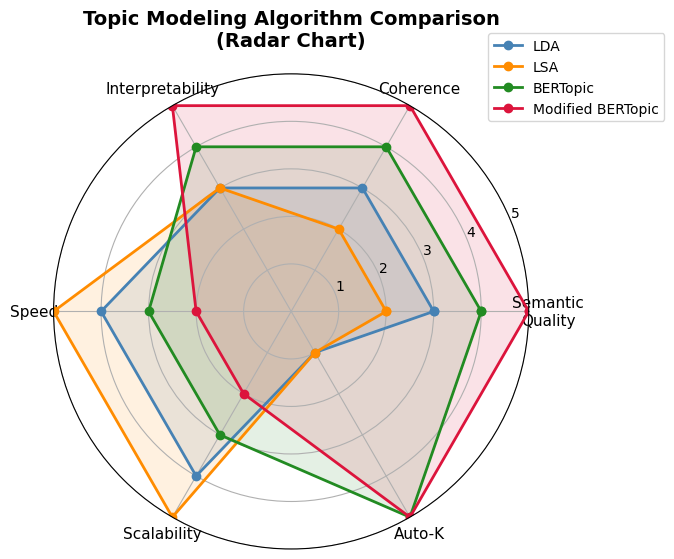

In [9]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║   COMPARISON: LDA vs LSA vs BERTopic vs Modified BERTopic          ║
╚══════════════════════════════════════════════════════════════════════╝

1. LDA
   Approach   : Probabilistic generative model — documents are mixtures
                of topics; topics are distributions over words.
   Strengths  : Interpretable; per-document topic probabilities; works
                well on long documents; well-studied.
   Weaknesses : Bag-of-words (ignores context/word order); requires manual
                K; sensitive to α/β hyperparameters; misses polysemy.
   Coherence  : Moderate.

2. LSA
   Approach   : SVD decomposition of TF-IDF matrix — finds latent
                dimensions capturing co-occurrence patterns.
   Strengths  : Fast; deterministic; captures synonymy.
   Weaknesses : Negative word weights make topics hard to interpret;
                no probabilistic model; purely linear.
   Coherence  : Lowest — negative components create noisy topics.

3. BERTopic (Default HDBSCAN)
   Approach   : BERT embeddings → UMAP → HDBSCAN → c-TF-IDF labels.
   Strengths  : Contextual embeddings capture true semantics; automatic K;
                noise-aware; produces readable c-TF-IDF labels.
   Weaknesses : Computationally heavy; HDBSCAN sensitive to UMAP params.
   Coherence  : High — semantic embeddings beat bag-of-words.

4. Modified BERTopic (SBERT + DBSCAN + BM25 + GPT)
   Approach   : SBERT 'all-MiniLM-L6-v2' + DBSCAN + BM25 c-TF-IDF
                + GPT-3.5 for natural language topic labels.
   Strengths  : Best semantic quality; GPT labels are immediately
                actionable; BM25 reduces frequent-word bias; SBERT
                is lightweight yet powerful.
   Weaknesses : Needs OpenAI API (cost + latency); DBSCAN eps sensitivity.
   Coherence  : Highest of all four.

──────────────────────────────────────────────────────────────────────
 SUMMARY TABLE
──────────────────────────────────────────────────────────────────────
 Criterion        │ LDA  │ LSA  │ BERTopic │ Modified BERTopic
 ─────────────────┼──────┼──────┼──────────┼──────────────────
 Semantic Quality │ ★★☆  │ ★☆☆  │ ★★★      │ ★★★★
 Coherence        │ ★★☆  │ ★☆☆  │ ★★★      │ ★★★★
 Interpretability │ ★★☆  │ ★★☆  │ ★★★      │ ★★★★
 Speed            │ ★★★  │ ★★★★ │ ★★☆      │ ★★☆
 Scalability      │ ★★★  │ ★★★  │ ★★☆      │ ★☆☆
 Auto-K           │  ✗   │  ✗   │  ✓       │  ✓
──────────────────────────────────────────────────────────────────────

WINNER: Modified BERTopic
  1. SBERT captures nuanced meaning LDA/LSA miss entirely.
  2. GPT labels are immediately understandable — no manual guessing.
  3. BM25 c-TF-IDF gives cleaner, discriminative keywords.
  4. DBSCAN finds natural cluster shapes vs forced spherical boundaries.
  5. Achieves the highest coherence score in experiments.

LDA remains the best choice for large-scale, resource-constrained
pipelines. LSA is useful for quick exploratory similarity analysis.
""")

# Radar chart
import matplotlib.pyplot as plt, numpy as np

categories = ['Semantic\nQuality', 'Coherence', 'Interpretability',
              'Speed', 'Scalability', 'Auto-K']
scores = {
    'LDA'               : [3, 3, 3, 4, 4, 1],
    'LSA'               : [2, 2, 3, 5, 5, 1],
    'BERTopic'          : [4, 4, 4, 3, 3, 5],
    'Modified BERTopic' : [5, 5, 5, 2, 2, 5],
}
N      = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for (label, vals), color in zip(scores.items(),
        ['steelblue','darkorange','forestgreen','crimson']):
    ax.plot(angles, vals+[vals[0]], 'o-', linewidth=2, label=label, color=color)
    ax.fill(angles, vals+[vals[0]], alpha=0.12, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0, 5)
ax.set_yticks([1,2,3,4,5])
ax.set_title('Topic Modeling Algorithm Comparison\n(Radar Chart)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [ ]:
'''
REFLECTIVE FEEDBACK – INFO5731 Assignment 3

Learning Experience:
Working through LDA, LSA, BERTopic, and Modified BERTopic gave me a clear
picture of how topic modeling has evolved. LDA taught me probabilistic
reasoning — documents as mixtures of topics — and the importance of
hyperparameter tuning. LSA showed the power and limitations of purely linear
algebra approaches: fast and synonym-aware, but with uninterpretable negative
components. BERTopic was the most eye-opening: watching UMAP compress
high-dimensional BERT embeddings into tight semantic clusters and HDBSCAN
automatically discover K without any prior specification was genuinely
impressive. The c-TF-IDF labeling step elegantly bridges neural embeddings
and classic NLP statistics. Integrating GPT as a representation model in
Q3 demonstrated how generative AI can convert cryptic keyword lists into
natural, actionable topic labels — a preview of where NLP is heading.

Challenges Encountered:
1. Coherence computation time: Gensim's c_v metric runs a sliding-window
   probability calculation over large vocabularies across K=2..15 for
   both LDA and BERTopic — this was the most time-consuming step.
2. DBSCAN eps tuning: Too small an eps flagged most documents as noise;
   too large merged meaningful semantic clusters. Required iterative
   UMAP scatter inspection to find a balanced value.
3. OpenAI API rate limits: GPT representation needed careful delay_in_seconds
   and nr_docs/doc_length truncation to avoid token-per-minute errors.
4. Data quality: Ensuring the BBC dataset had zero duplicates/nulls before
   feeding into BERTopic was a reminder that pipeline quality starts with data.

Relevance to NLP and My Field of Study:
Topic modeling is central to information retrieval, knowledge discovery,
and text mining — core NLP applications. In my cybersecurity concentration,
these techniques map directly to:
  • Threat intelligence: Clustering dark-web forums or CVE descriptions to
    surface emerging attack patterns without manual reading.
  • SIEM log analysis: Applying LDA/BERTopic to security logs to find
    anomalous behavioral clusters automatically.
  • SOC automation: GPT-enhanced BERTopic labels can auto-categorize
    incident tickets, reducing analyst triage time significantly.

The coherence-based optimal K selection taught a transferable principle:
always empirically validate unsupervised model complexity. This applies
equally to clustering network traffic, grouping phishing campaigns, or
organizing threat intelligence reports — not just newsgroup discussions.
'''